Shape of the dataset: (74, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   74 non-null     int64 
 1   date                 74 non-null     object
 2   team1                74 non-null     object
 3   team2                74 non-null     object
 4   toss_winner          74 non-null     object
 5   decision             71 non-null     object
 6   first_score          74 non-null     int64 
 7   first_wkts           74 non-null     int64 
 8   second_score         74 non-null     int64 
 9   second_wkts          74 non-null     int64 
 10  winner               74 non-null     object
 11  player_of_the_match  71 non-null     object
 12  most_runs            71 non-null     object
 13  most_wkts            71 non-null     object
dtypes: int64(5), object(9)
memory usage: 8.2+ KB

Missing values:
 id            

,Matches Played
Hyderabad,17
Kolkata,16
Rajasthan,16
Banglore,15
Delhi,14
Gujarat,14
Punjab,14
Chennai,14
Lucknow,14
Mumbai,14


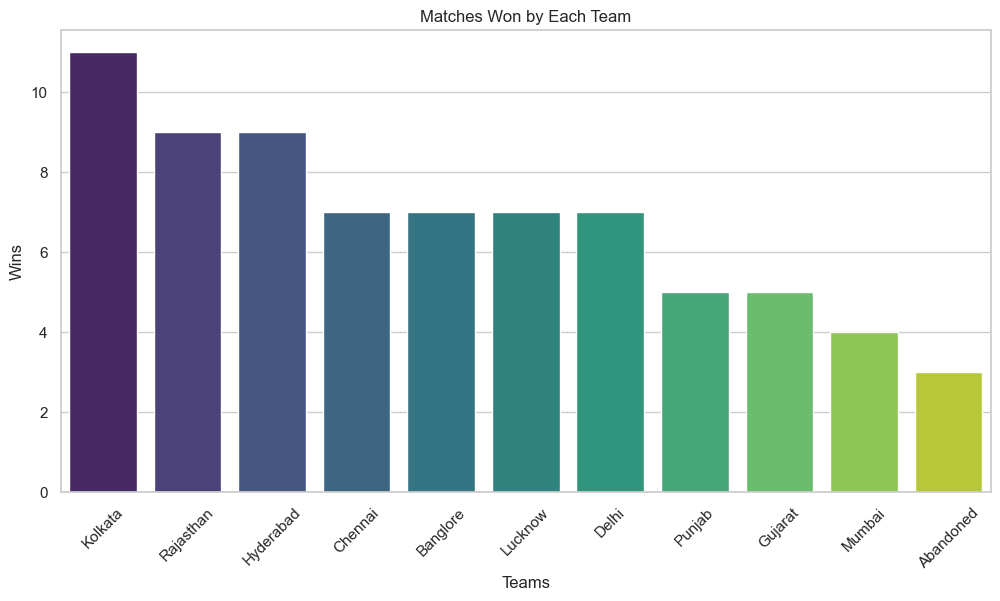

🏆 The most successful team in IPL 2024 is: Kolkata with 11 wins.


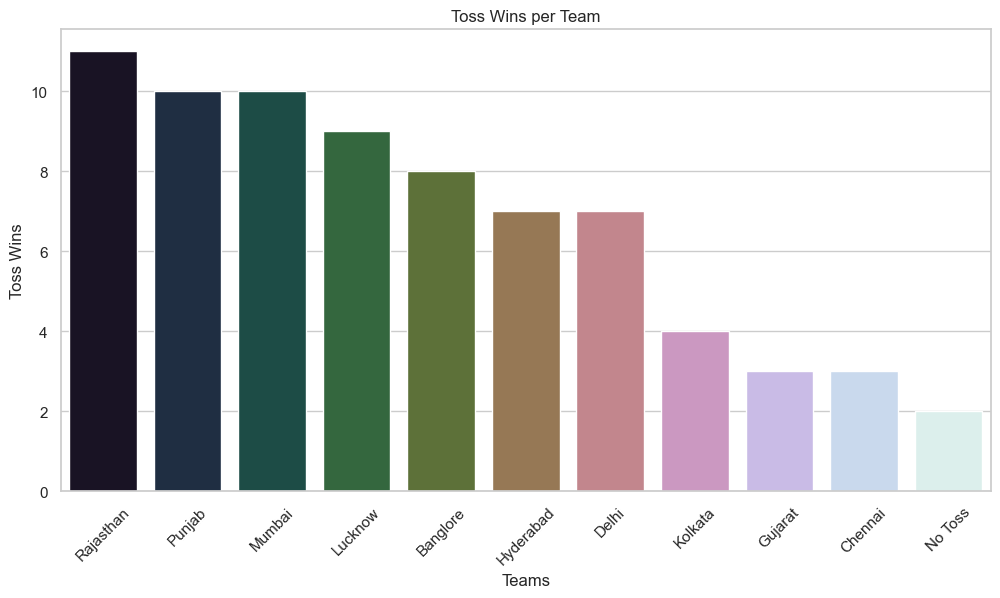

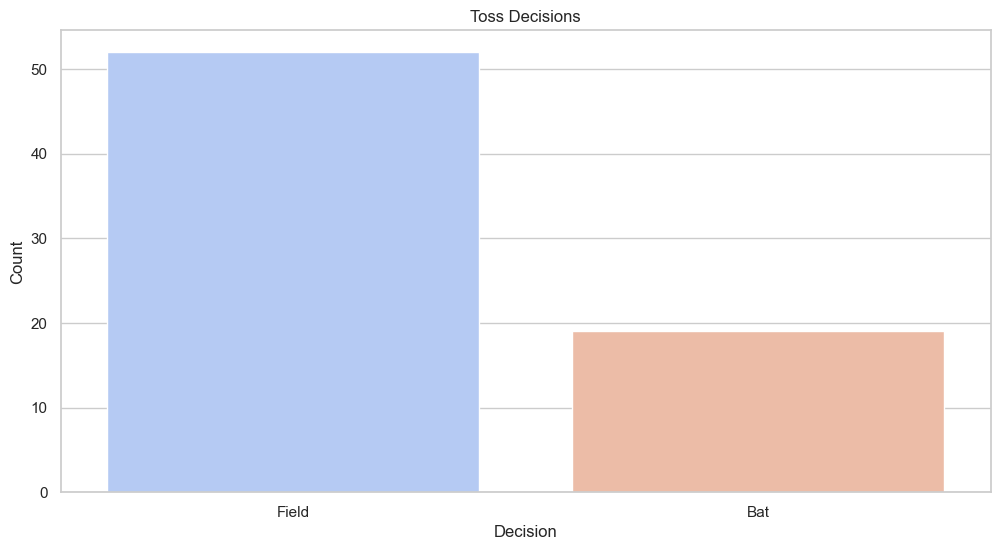

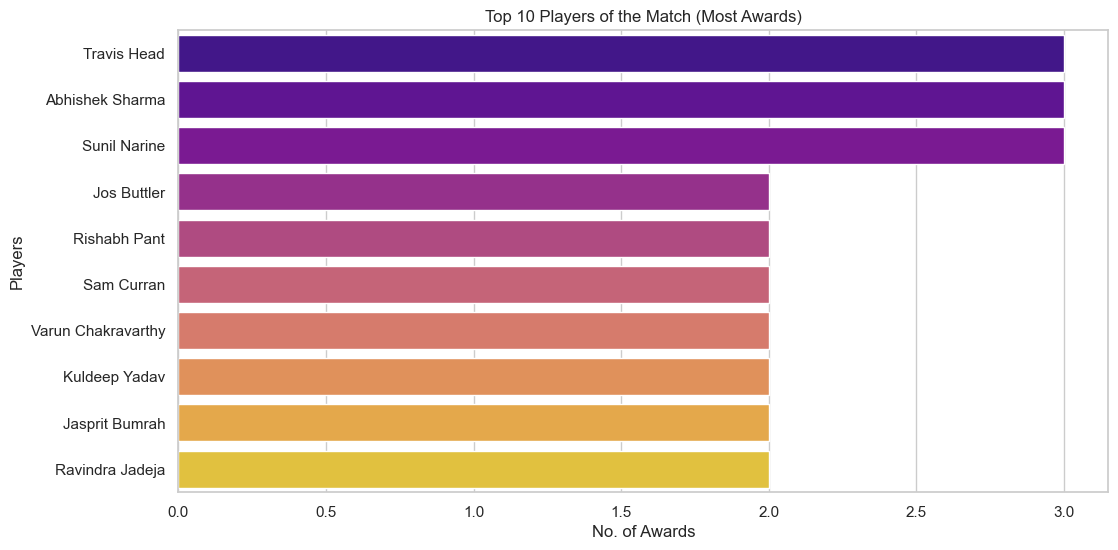

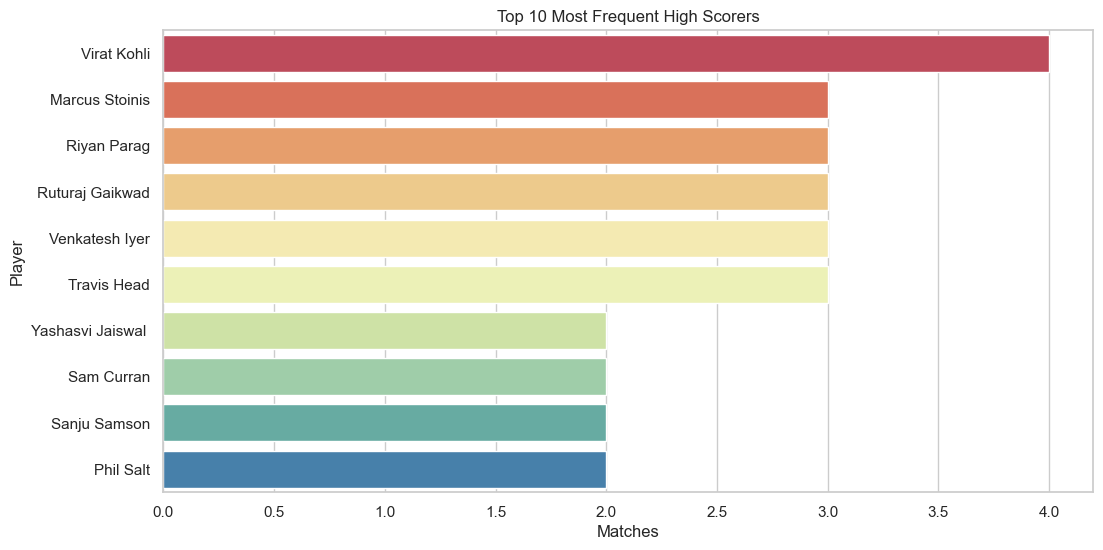

Average First Innings Score: 180.55
Average Second Innings Score: 169.05


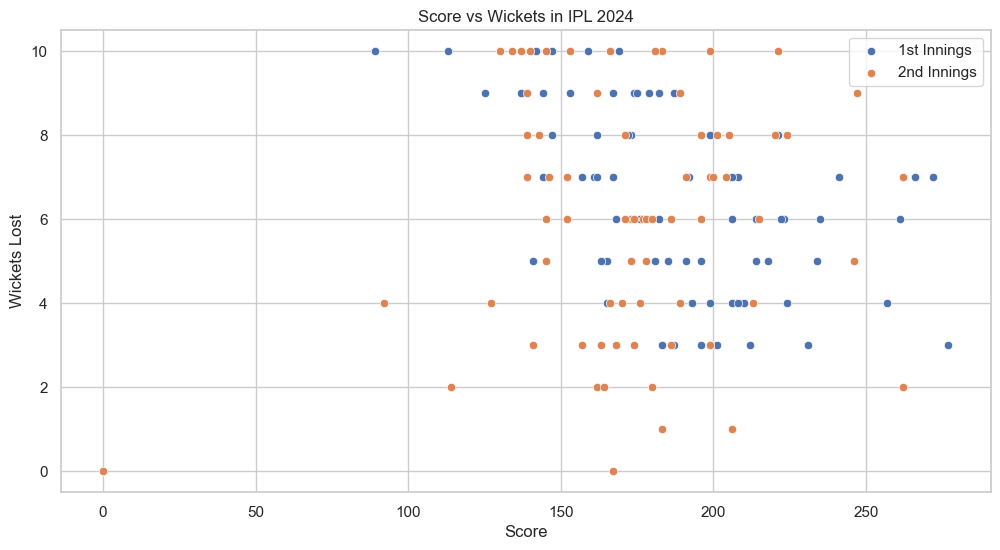

In [2]:
# IPL 2024 Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Loading of data
df = pd.read_csv('Ipl_analysis.csv')
print("Shape of the dataset:", df.shape)
df.info()
df.describe()
print("\nMissing values:\n", df.isnull().sum() ) #checks for any kind of missing values

# Total number of  matches played
total_matches = df.shape[0]
print("\nTotal Matches Played:", total_matches)

# Participating teams
teams = sorted(set(df['team1']).union(set(df['team2'])))
print("Participating Teams:", teams)

# Matches played by each team
from collections import Counter
match_counts = Counter(df['team1'].tolist() + df['team2'].tolist())
match_df = pd.DataFrame.from_dict(match_counts, orient='index', columns=['Matches Played'])
match_df = match_df.sort_values(by='Matches Played', ascending=False)
display(match_df)

# Matches won by teams
win_counts = df['winner'].value_counts()
sns.barplot(x=win_counts.index, y=win_counts.values, hue=win_counts.index, palette='viridis', legend=False)
plt.title("Matches Won by Each Team")
plt.xticks(rotation=45)
plt.ylabel("Wins")
plt.xlabel("Teams")
plt.show()

# Most successful team of ipl 2024
most_winning_team = win_counts.idxmax()
print(f"🏆 The most successful team in IPL 2024 is: {most_winning_team} with {win_counts.max()} wins.")

# Toss wins
toss_wins = df['toss_winner'].value_counts()
sns.barplot(x=toss_wins.index, y=toss_wins.values, hue=toss_wins.index, palette='cubehelix', legend=False)
plt.title("Toss Wins per Team")
plt.xticks(rotation=45)
plt.ylabel("Toss Wins")
plt.xlabel("Teams")
plt.show()

# Toss decisions
toss_decision = df['decision'].value_counts()
sns.barplot(x=toss_decision.index, y=toss_decision.values, hue=toss_decision.index, palette='coolwarm', legend=False)
plt.title("Toss Decisions")
plt.ylabel("Count")
plt.xlabel("Decision")
plt.show()

# Top 10 Player of the Match awards
pom_counts = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=pom_counts.values, y=pom_counts.index, hue=pom_counts.index, palette='plasma', legend=False)
plt.title("Top 10 Players of the Match (Most Awards)")
plt.xlabel("No. of Awards")
plt.ylabel("Players")
plt.show()

# Top 10 most frequent high scorers
top_scorers = df[['most_runs']].value_counts().head(10)
top_scorers_df = top_scorers.reset_index(name='Count')
sns.barplot(data=top_scorers_df, y='most_runs', x='Count', hue='most_runs', palette='Spectral', legend=False)
plt.title("Top 10 Most Frequent High Scorers")
plt.xlabel("Matches")
plt.ylabel("Player")
plt.show()

# Average scores
avg_first_score = df['first_score'].mean()
avg_second_score = df['second_score'].mean()
print(f"Average First Innings Score: {avg_first_score:.2f}")
print(f"Average Second Innings Score: {avg_second_score:.2f}")

# Scatterplot: Score vs Wickets
sns.scatterplot(data=df, x='first_score', y='first_wkts', label='1st Innings')
sns.scatterplot(data=df, x='second_score', y='second_wkts', label='2nd Innings')
plt.title("Score vs Wickets in IPL 2024")
plt.xlabel("Score")
plt.ylabel("Wickets Lost")
plt.legend()
plt.show()
